<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-11 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Generative Adversarial Networks </21> </html>

### Demonstration how to generate images of handwritten digits (like MNIST dataset) using
### a Deep Convolutional Generative Adversarial Network (DCGAN)

[source](https://arxiv.org/pdf/1511.06434.pdf)

![sample output](https://tensorflow.org/images/gan/dcgan.gif)

##### (GANs) can be described as models which are trained simultaneously by an adversarial process.
A *generator* learns to create images that look real, while a *discriminator* learns to tell real images apart from fakes.
During training, the *generator* progressively becomes better at creating images that look real, while the *discriminator becomes better at telling them apart. The process reaches equilibrium when the *discriminator* can no longer distinguish real images from fakes.

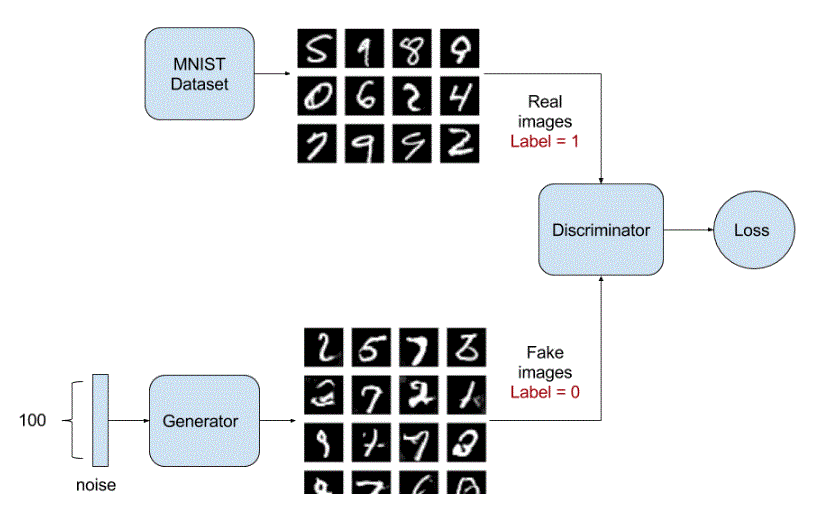

##### This notebook uses on the MNIST dataset. The following animation shows a series of images produced by the *generator* as it was trained for 50 epochs. The images begin as random noise, and increasingly resemble hand written digits over time.

### Import

image.png

In [1]:
import tensorflow as tf

In [2]:
#

image.png

In [3]:
tf.__version__

'2.19.0'

In [4]:
#

______________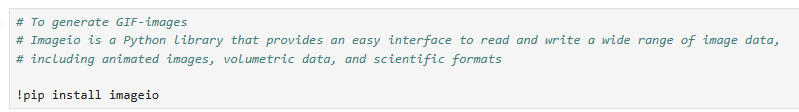

In [5]:
pip install imageio

In [6]:
#

______________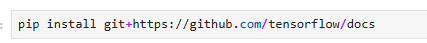

In [7]:
pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-4y1yrimh
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-4y1yrimh
  Resolved https://github.com/tensorflow/docs to commit 7c3650212740204359d4ceae481abc79345541be
  Preparing metadata (setup.py) ... done


In [8]:
#

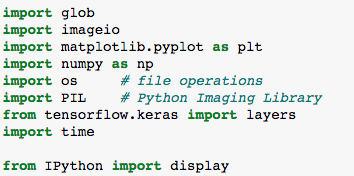


In [9]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time
from IPython import display

In [10]:
#

### MNIST Dataset
After treining the generator will generate handwritten digits resembling the MNIST data.


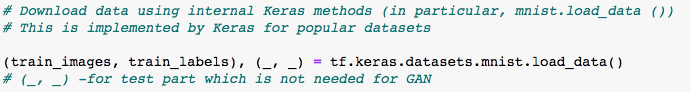

In [11]:
(train_images, train_labels), (_,_) = tf.keras.datasets.mnist.load_data()

In [12]:
#

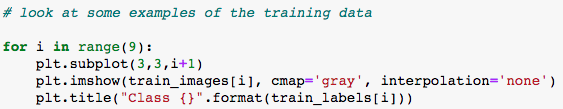

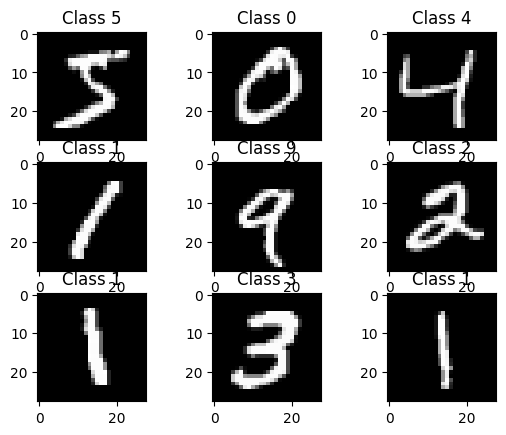

In [13]:
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(train_images[i],cmap='gray', interpolation='none')
  plt.title("Class {}" .format(train_labels[i]))

In [14]:
#

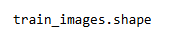

In [15]:
train_images.shape

(60000, 28, 28)

In [16]:
#

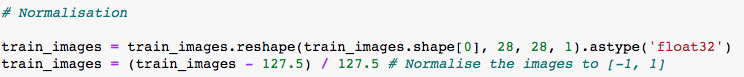

In [17]:
train_images=train_images.reshape(train_images.shape[0], 28, 28,1).astype('float32')
test_images=(train_images- 127.5)/127.5

In [18]:
#

_______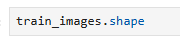

In [19]:
train_images.shape

(60000, 28, 28, 1)

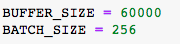

In [20]:
from collections.abc import Buffer
Buffer_size =60000
batch_size = 256

In [21]:
#

In [22]:
#tf.data.Dataset.from_tensor_slices?

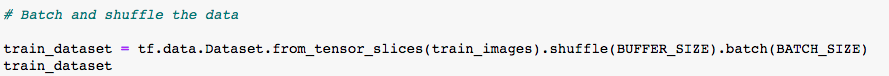

In [23]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(Buffer_size).batch(batch_size)
train_dataset

<_BatchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None)>

In [24]:
#

### The Generator

The generator uses `tf.keras.layers.Conv2DTranspose` (upsampling) layers to produce an image from a seed (random noise). Start with a `Dense` layer that takes this seed as input, then upsample several times until you reach the desired image size of 28x28x1. Notice the `tf.keras.layers.LeakyReLU` activation for each layer, except the output layer which uses tanh.

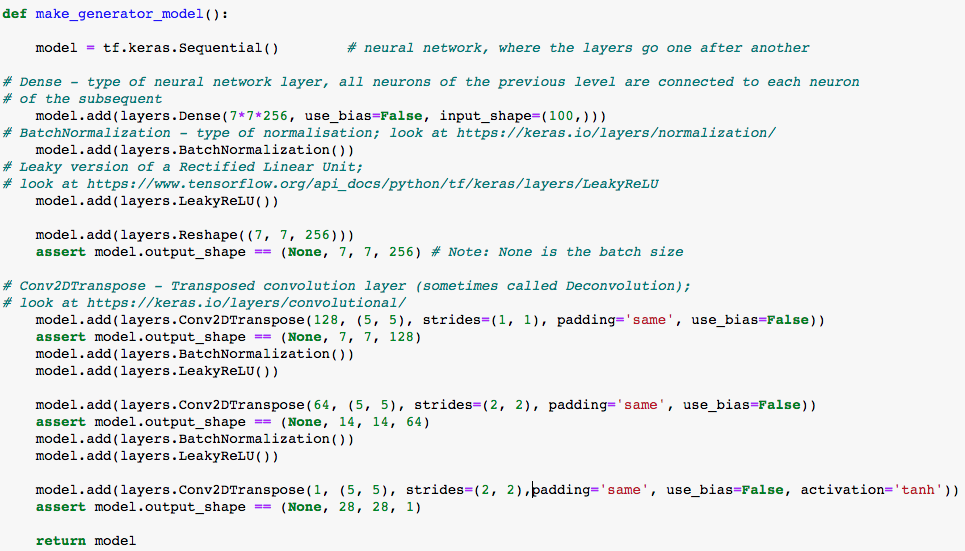


In [25]:
def make_generator_model():
    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)


    return model


In [26]:
#

Use the generator to create an image.


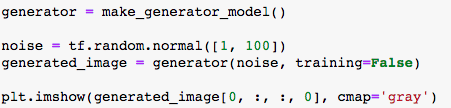



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


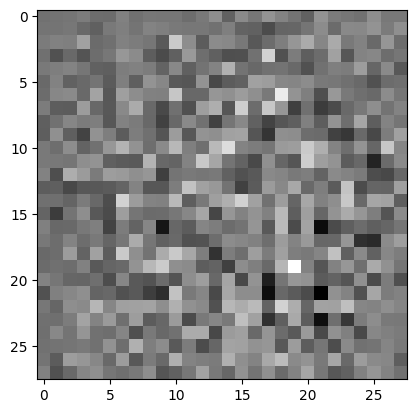

In [27]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)
plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [28]:
#

image.png



In [29]:
generator?

In [30]:
# Describe why the image does not have a structure?

In [31]:
#

### The Discriminator

The discriminator is a CNN-based image classifier.

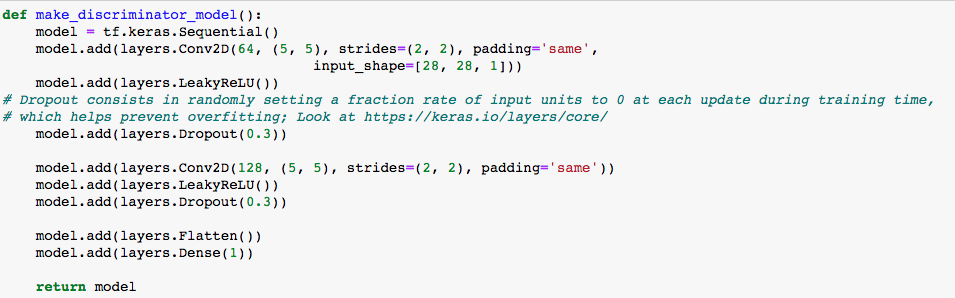

In [32]:
def make_discriminator_model():
  model= tf.keras.Sequential()
  model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[28,28,1]))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same'))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))

  model.add(layers.Flatten())
  model.add(layers.Dense(1))

  return model


In [33]:
#

Use the (as yet untrained) discriminator to classify the generated images as real or fake. The model will be trained to output positive values for real images, and negative values for fake images.

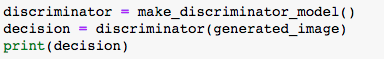

In [34]:
discriminator= make_discriminator_model()
decision=discriminator(generated_image)
print(decision)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[-0.00295487]], shape=(1, 1), dtype=float32)


image.png

## Define the loss and optimizers

Define loss functions and optimizers for both models.


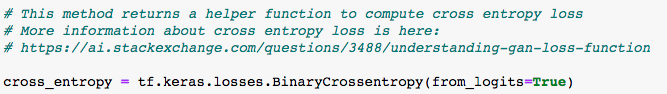

In [35]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [36]:
#

### Discriminator loss

This method quantifies how well the discriminator is able to distinguish real images from fakes. It compares the discriminator's predictions on real images to an array of 1s, and the discriminator's predictions on fake (generated) images to an array of 0s.

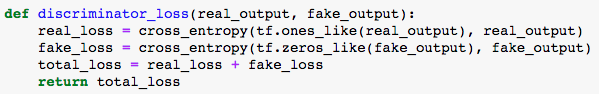

In [37]:
def discriminator_loss(real_output, fake_output):
  real_loss=cross_entropy(tf.ones_like(real_output),real_output)
  fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
  total_loss = real_loss + fake_loss
  return total_loss

In [38]:
#

### Generator loss
The generator's loss quantifies how well it was able to trick the discriminator. Intuitively, if the generator is performing well, the discriminator will classify the fake images as real (or 1). Here, we will compare the discriminators decisions on the generated images to an array of 1s.

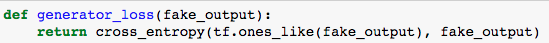

In [39]:
def generator_loss(fake_output):
  return cross_entropy(tf.ones_like(fake_output), fake_output)

In [40]:
#

The discriminator and the generator optimizers are different since we will train two networks separately.

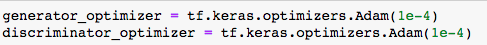

In [41]:
generator_optimizer= tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer= tf.keras.optimizers.Adam(1e-4)

In [42]:
#

image.png

In [43]:
tf.keras.optimizers.Adam

keras.src.optimizers.adam.Adam

### Save checkpoints
It is useful in case a long running training task is interrupted.


image.png

In [44]:
tf.train.Checkpoint

tensorflow.python.checkpoint.checkpoint.Checkpoint

In [45]:
#

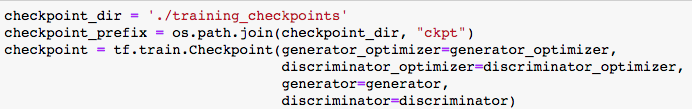

In [46]:
checkpoint_dir ='./training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [47]:
#

## Training loop



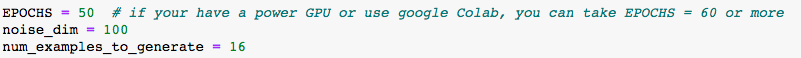


In [48]:
EPOCHS=16
noise_dim =100
num_examples_to_generator =16

In [49]:
#

image.png

In [50]:
tf.random.normal

<function tensorflow.python.ops.random_ops.random_normal(shape, mean=0.0, stddev=1.0, dtype=tf.float32, seed=None, name=None)>

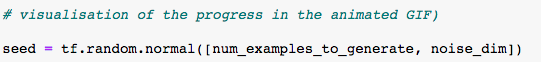

In [51]:
seed =tf.random.normal([num_examples_to_generator, noise_dim])

In [52]:
#

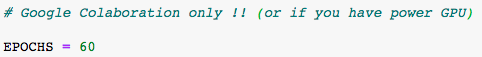

In [53]:
#

The training loop begins with generator receiving a random seed as input. That seed is used to produce an image. The discriminator is then used to classify real images (drawn from the training set) and fakes images (produced by the generator). The loss is calculated for each of these models, and the gradients are used to update the generator and discriminator.

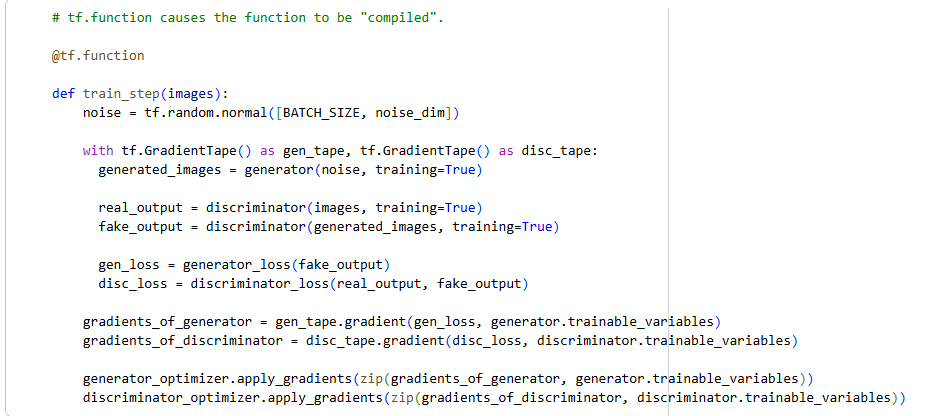

In [54]:
@tf.function
def train_step(images):
  noise=tf.random.normal([batch_size, noise_dim])

  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    generated_images=generator(noise, training=True)

    real_output=discriminator(images, training=True)
    fake_output=discriminator(generated_images, training=True)

    gen_loss=generator_loss(fake_output)
    disc_loss=discriminator_loss(real_output, fake_output)

    gradients_of_generator=gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator=disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [55]:
#

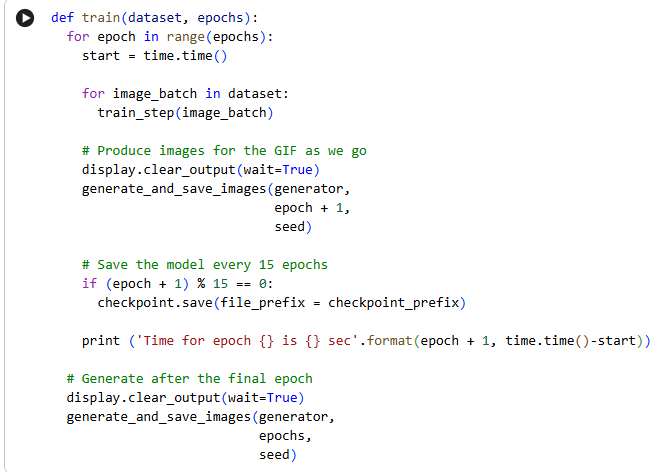

In [68]:
def train(Dataset, EPOCHS):
  for epoch in range(EPOCHS):
    start=time.time()

    for image_batch in Dataset:
      train_step(image_batch)

      display.clear_output(wait=True)
      generate_and_save_images(generator, epoch + 1, seed)

      if (epoch + 1) % 15 == 0:
        checkpoint.save(file_prefix = checkpoint_prefix)

      print('Time for epoch{} is {} sec'.format(epoch +1, time.time()-start))

      display.clear_output(wait=True)
      generator_and_save_images(generator, EPOCHS, seed)



In [57]:
#

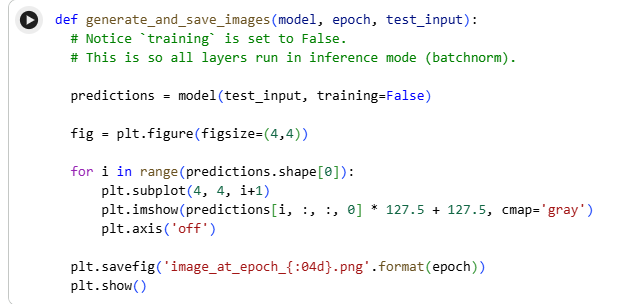

**Generate and save images**



In [69]:
def generate_and_save_images(model, EPOCHS, test_input):

  predictions=model(test_input, training=False)

  fig = plt.figure(figsize=(4,4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(EPOCHS))
  plt.show()

In [59]:
#

## Train the model
train() - training the generator and discriminator simultaneously.
It's important that the generator and discriminator do not overpower each other (e.g., that they train at a similar rate).

At the beginning of the training, the generated images look like random noise. As training progresses, the generated digits will look increasingly real. After about 50 epochs, they resemble MNIST digits.

In [60]:
# Save your Jupyter Notebook before start the next cell

### Before starting the next cell, read the Lab Logbook requirements.
### To take a screenshot of the required epoch, use Shift+Window+S for Windows
### and Shift+Command+5 for Mac.

image.png

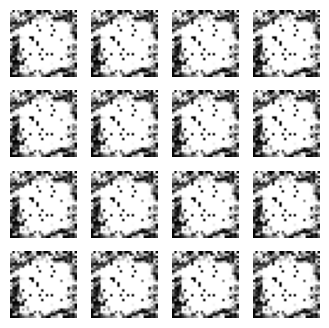

In [70]:
train(train_dataset, EPOCHS)

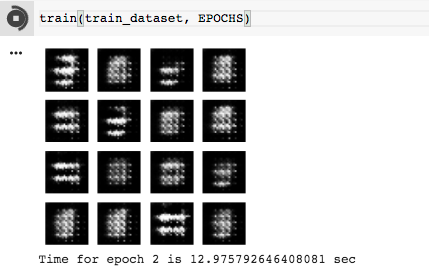

image.png

Restore the latest checkpoint.

image.png

In [71]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

In [ ]:
#

### Show the result as a GIF-file


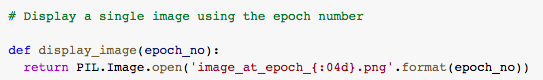

In [72]:
def display_image(epoch_no):
  return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

In [ ]:
#

image.png

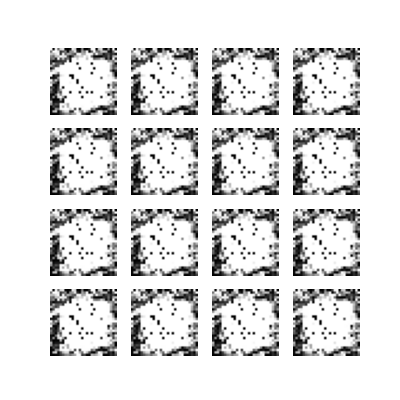

In [73]:
display_image(EPOCHS)

In [ ]:
# describe the results

Use `imageio` to create an animated gif using the images saved during training.

_________________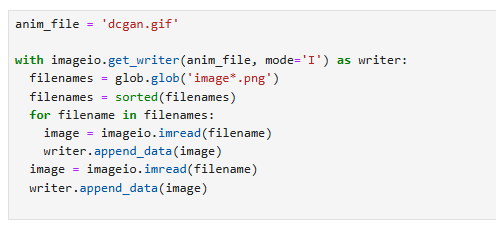

In [74]:
anim_file='dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames= glob.glob('image*.png')
  filenames=sorted(filenames)
  for filename in filenames:
    image=imageio.imread(filename)
    writer.append_data(image)
  image=imageio.imread(filename)
  writer.append_data(image)

/tmp/ipykernel_22817/2430629170.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image=imageio.imread(filename)
/tmp/ipykernel_22817/2430629170.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image=imageio.imread(filename)


In [ ]:
#

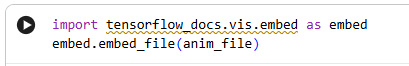


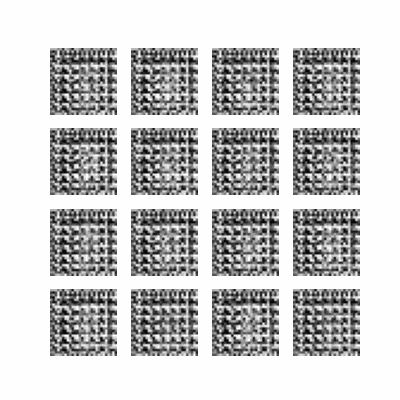

In [76]:
import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)

If you're working in Colab you can download the animation with the code below:

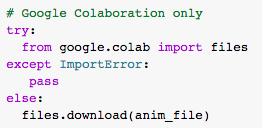

In [77]:
try:
  from google.colab import files
except ImportError:
    pass
else:
  files.download(anim_file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### You must copy a screenshot of the GAN training result at a specific epoch to your logbook. The screenshot must contain the digital images, the epoch number and the time spent training for this epoch.

### Determine this epoch number using the following method:

#### Take the last two digits from your SID.
#### If this number is less than or equal to 50, it is the required epoch number.
#### If it exceeds 50, divide it by 50 and round up if necessary.
#### For example, if your SID is 2187467, and the last two digits are 67, which is greater than 50.
#### Divide by 2, resulting in 33.5. Round up to 34, and this becomes your epoch number.

<html> <h4 style="font-style:bold; color:red;"> NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB. </h4> </html>